**Task 3:  Forest Cover Type Classification**

In [8]:
#libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [9]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("covertype.csv")
df.head()


Saving covertype.csv to covertype.csv


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,5


In [10]:
df.info()
df["Cover_Type"].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Unnamed: 0                          581012 non-null  int64  
 1   Unnamed: 1                          581012 non-null  int64  
 2   Unnamed: 2                          581012 non-null  int64  
 3   Elevation                           581012 non-null  int64  
 4   Aspect                              581012 non-null  int64  
 5   Slope                               581012 non-null  int64  
 6   Horizontal_Distance_To_Hydrology    581012 non-null  int64  
 7   Vertical_Distance_To_Hydrology      581012 non-null  int64  
 8   Horizontal_Distance_To_Roadways     581012 non-null  int64  
 9   Hillshade_9am                       581012 non-null  int64  
 10  Hillshade_Noon                      581012 non-null  int64  
 11  Hillshade_3pm             

,count
Cover_Type,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747


In [11]:
df.isnull().sum().sum()
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]



Train- Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



###**Train random forest**

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [14]:
y_pred_rf = rf.predict(X_test)


In [15]:
#Result Check
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



Accuracy: 0.9541836269287368
              precision    recall  f1-score   support

           1       0.96      0.94      0.95     42368
           2       0.95      0.97      0.96     56661
           3       0.94      0.96      0.95      7151
           4       0.92      0.84      0.88       549
           5       0.95      0.77      0.85      1899
           6       0.93      0.90      0.91      3473
           7       0.98      0.94      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.95      0.90      0.92    116203
weighted avg       0.95      0.95      0.95    116203



####Confusion Matrix

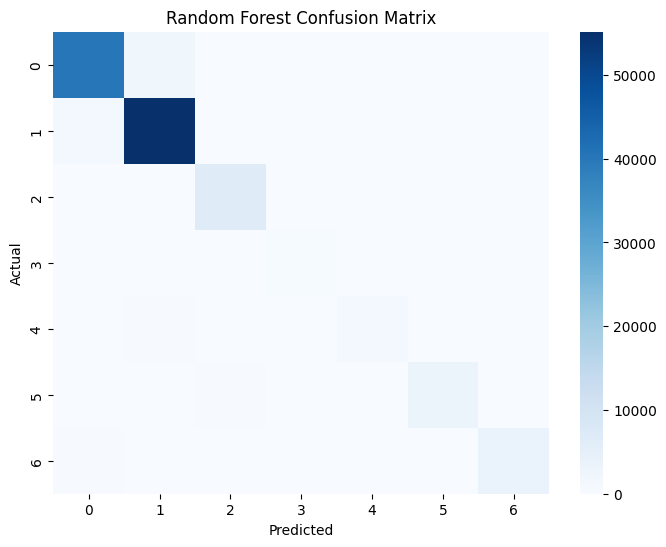

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


Feature Importance

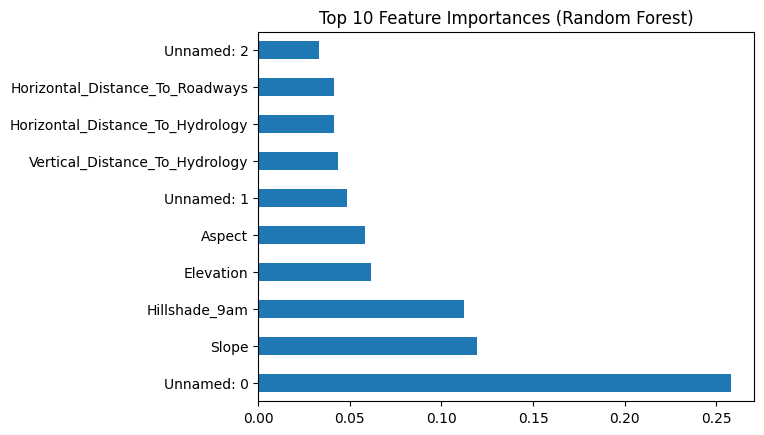

In [17]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind="barh")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()



####Model 2 XGBoost

In [18]:
y_train = y_train + 1
y_test = y_test + 1


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=7,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)




In [23]:
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [24]:
#Cehck Result
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


Accuracy: 0.9228505288159514
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     42557
           1       0.92      0.94      0.93     56500
           2       0.95      0.96      0.95      7121
           3       0.92      0.85      0.88       526
           4       0.92      0.79      0.85      1995
           5       0.92      0.91      0.91      3489
           6       0.97      0.96      0.96      4015

    accuracy                           0.92    116203
   macro avg       0.93      0.90      0.91    116203
weighted avg       0.92      0.92      0.92    116203



Bonus Part

In [26]:
##Hyper Parameter Turning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)




In [27]:
grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [28]:
best_rf = grid.best_estimator_


AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'